In [1]:
#Image size : 224 * 224 *3 
# Conv Layer : filter size : 3*3 , stride =1 , padding = same 
# Max Pooling layer : filter size : 2*2 , stride = 2

# VGG-16 ARCHITECTURE
# Block 1
# Conv 3×3, 64
# Conv 3×3, 64
# MaxPool 2×2
# Output: 112 × 112 × 64

# Block 2
# Conv 3×3, 128
# Conv 3×3, 128
# MaxPool 2×2
# Output: 56 × 56 × 128

# Block 3
# Conv 3×3, 256
# Conv 3×3, 256
# Conv 3×3, 256
# MaxPool 2×2
# Output: 28 × 28 × 256

# Block 4
# Conv 3×3, 512
# Conv 3×3, 512
# Conv 3×3, 512
# MaxPool 2×2
# Output: 14 × 14 × 512

# Block 5
# Conv 3×3, 512
# Conv 3×3, 512
# Conv 3×3, 512
# MaxPool 2×2
# Output: 7 × 7 × 512

# FC layers
# Flatten: 25088
# Dense 4096
# Dense 4096
# Dense 1000

# Summary
# Conv layers: 13
# FC layers: 3
# Pool layers: 5
# Total: VGG-16

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load Dataset

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% train, 20% validation
)

## Train Set

In [6]:
train_data = datagen.flow_from_directory(
    "/Users/sadhanauprety/Desktop/DL/NN/CNN/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 2198 images belonging to 5 classes.


In [7]:
DATASET_PATH = "/Users/sadhanauprety/Desktop/DL/NN/CNN/train"

In [8]:
val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 548 images belonging to 5 classes.


## Classes

In [9]:
print(train_data.class_indices)

{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


## Loading VGG

In [11]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 31s 1us/step


In [12]:
for layer in base_model.layers:
    layer.trainable = False

In [13]:
## Update Classifier 

In [15]:
from tensorflow.keras.layers import Flatten, Dense, Dropout
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(5, activation="softmax")(x)

In [18]:
model = Model(inputs=base_model.input, outputs=output)

In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 346s 5s/step - accuracy: 0.5605 - loss: 1.5326 - val_accuracy: 0.7153 - val_loss: 0.7834
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 357s 5s/step - accuracy: 0.7370 - loss: 0.7171 - val_accuracy: 0.7427 - val_loss: 0.6814
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 377s 5s/step - accuracy: 0.7884 - loss: 0.5688 - val_accuracy: 0.8011 - val_loss: 0.5661
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 435s 6s/step - accuracy: 0.8253 - loss: 0.4665 - val_accuracy: 0.7774 - val_loss: 0.5926
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 446s 6s/step - accuracy: 0.8567 - loss: 0.3829 - val_accuracy: 0.7993 - val_loss: 0.5996
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 440s 6s/step - accuracy: 0.8840 - loss: 0.3223 - val_accuracy: 0.7993 - val_loss: 0.5102
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 465s 7s/step - accuracy: 0.9035 - loss: 0.2684 - val_accuracy: 0.8011 - val_loss: 0.5720
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 457s 7s/step - accuracy: 0.9195 - loss: 0.2221 - val_accuracy: 0.7974 - v

In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,986,897 (129.65 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 12,848,140 (49.01 MB)

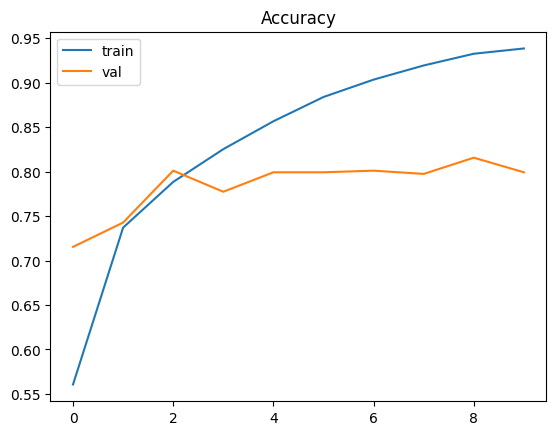

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()